In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [5]:
df.shape

(3556, 24)

In [6]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,mapsko mount ville,sector 79,1.10,12731.0,864.0,Super Built up area 1490(138.43 sq.m.)Carpet a...,3,3,3,22.0,South-West,Relatively New,1490.0,NaN,863.91,1,0,0,1,0,0,135,288.000000
1,flat,ansal estella,sector 103,1.50,8671.0,1730.0,Super Built up area 1730(160.72 sq.m.)Carpet a...,3,3,3+,6.0,NaN,Under Construction,1730.0,NaN,1725.00,0,0,0,0,0,0,58,576.666667
2,flat,chd avenue,sector 71,0.95,7930.0,1198.0,Super Built up area 1198(111.3 sq.m.),2,2,2,5.0,South,Moderately Old,1198.0,NaN,NaN,0,0,0,0,0,1,142,599.000000
3,flat,ats triumph,sector 104,1.75,7642.0,2290.0,Super Built up area 2290(212.75 sq.m.)Carpet a...,3,4,3+,12.0,North-West,Relatively New,2290.0,NaN,1800.00,1,1,0,1,1,1,21,763.333333
4,flat,breez global heights,sohna road,0.46,6479.0,710.0,Carpet area: 710 (65.96 sq.m.),2,2,2,6.0,East,Relatively New,NaN,NaN,710.00,0,0,0,0,0,2,49,355.000000


In [7]:
train_df = df.drop(columns=['society','price_per_sqft'])

In [8]:
train_df.head()

,property_type,sector,price,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,sector 79,1.10,864.0,Super Built up area 1490(138.43 sq.m.)Carpet a...,3,3,3,22.0,South-West,Relatively New,1490.0,NaN,863.91,1,0,0,1,0,0,135,288.000000
1,flat,sector 103,1.50,1730.0,Super Built up area 1730(160.72 sq.m.)Carpet a...,3,3,3+,6.0,NaN,Under Construction,1730.0,NaN,1725.00,0,0,0,0,0,0,58,576.666667
2,flat,sector 71,0.95,1198.0,Super Built up area 1198(111.3 sq.m.),2,2,2,5.0,South,Moderately Old,1198.0,NaN,NaN,0,0,0,0,0,1,142,599.000000
3,flat,sector 104,1.75,2290.0,Super Built up area 2290(212.75 sq.m.)Carpet a...,3,4,3+,12.0,North-West,Relatively New,2290.0,NaN,1800.00,1,1,0,1,1,1,21,763.333333
4,flat,sohna road,0.46,710.0,Carpet area: 710 (65.96 sq.m.),2,2,2,6.0,East,Relatively New,NaN,NaN,710.00,0,0,0,0,0,2,49,355.000000


### luxury score

<Axes: ylabel='luxury_score'>

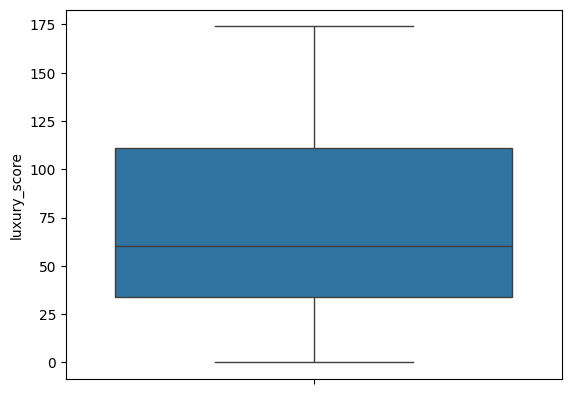

In [9]:
sns.boxplot(df['luxury_score'])

In [10]:
def categorize_luxury(score):
    if 0 <= score < 50:
        return "Low"
    elif 50 <= score < 150:
        return "Medium"
    elif 150 <= score <= 175:
        return "High"
    else:
        return None  # or "Undefined" or any other label for scores outside the defined bins

In [11]:
train_df['luxury_category'] = train_df['luxury_score'].apply(categorize_luxury)

In [12]:
train_df.head()

,property_type,sector,price,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio,luxury_category
0,flat,sector 79,1.10,864.0,Super Built up area 1490(138.43 sq.m.)Carpet a...,3,3,3,22.0,South-West,Relatively New,1490.0,NaN,863.91,1,0,0,1,0,0,135,288.000000,Medium
1,flat,sector 103,1.50,1730.0,Super Built up area 1730(160.72 sq.m.)Carpet a...,3,3,3+,6.0,NaN,Under Construction,1730.0,NaN,1725.00,0,0,0,0,0,0,58,576.666667,Medium
2,flat,sector 71,0.95,1198.0,Super Built up area 1198(111.3 sq.m.),2,2,2,5.0,South,Moderately Old,1198.0,NaN,NaN,0,0,0,0,0,1,142,599.000000,Medium
3,flat,sector 104,1.75,2290.0,Super Built up area 2290(212.75 sq.m.)Carpet a...,3,4,3+,12.0,North-West,Relatively New,2290.0,NaN,1800.00,1,1,0,1,1,1,21,763.333333,Low
4,flat,sohna road,0.46,710.0,Carpet area: 710 (65.96 sq.m.),2,2,2,6.0,East,Relatively New,NaN,NaN,710.00,0,0,0,0,0,2,49,355.000000,Low


### floorNum

<Axes: ylabel='floorNum'>

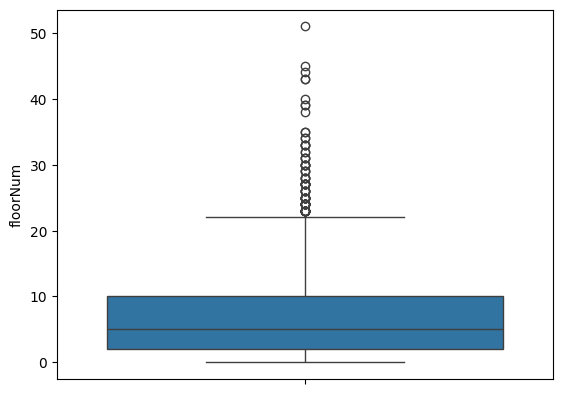

In [13]:
sns.boxplot(df['floorNum'])

In [14]:
def categorize_floor(floor):
    if 0 <= floor <= 2:
        return "Low Floor"
    elif 3 <= floor <= 10:
        return "Mid Floor"
    elif 11 <= floor <= 51:
        return "High Floor"
    else:
        return None  # or "Undefined" or any other label for floors outside the defined bins

In [15]:
train_df['floor_category'] = train_df['floorNum'].apply(categorize_floor)

In [16]:
train_df.head()

,property_type,sector,price,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio,luxury_category,floor_category
0,flat,sector 79,1.10,864.0,Super Built up area 1490(138.43 sq.m.)Carpet a...,3,3,3,22.0,South-West,Relatively New,1490.0,NaN,863.91,1,0,0,1,0,0,135,288.000000,Medium,High Floor
1,flat,sector 103,1.50,1730.0,Super Built up area 1730(160.72 sq.m.)Carpet a...,3,3,3+,6.0,NaN,Under Construction,1730.0,NaN,1725.00,0,0,0,0,0,0,58,576.666667,Medium,Mid Floor
2,flat,sector 71,0.95,1198.0,Super Built up area 1198(111.3 sq.m.),2,2,2,5.0,South,Moderately Old,1198.0,NaN,NaN,0,0,0,0,0,1,142,599.000000,Medium,Mid Floor
3,flat,sector 104,1.75,2290.0,Super Built up area 2290(212.75 sq.m.)Carpet a...,3,4,3+,12.0,North-West,Relatively New,2290.0,NaN,1800.00,1,1,0,1,1,1,21,763.333333,Low,High Floor
4,flat,sohna road,0.46,710.0,Carpet area: 710 (65.96 sq.m.),2,2,2,6.0,East,Relatively New,NaN,NaN,710.00,0,0,0,0,0,2,49,355.000000,Low,Mid Floor


In [17]:
train_df.drop(columns=['floorNum','luxury_score'],inplace=True)

In [18]:
train_df.head()

,property_type,sector,price,area,areaWithType,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,area_room_ratio,luxury_category,floor_category
0,flat,sector 79,1.10,864.0,Super Built up area 1490(138.43 sq.m.)Carpet a...,3,3,3,South-West,Relatively New,1490.0,NaN,863.91,1,0,0,1,0,0,288.000000,Medium,High Floor
1,flat,sector 103,1.50,1730.0,Super Built up area 1730(160.72 sq.m.)Carpet a...,3,3,3+,NaN,Under Construction,1730.0,NaN,1725.00,0,0,0,0,0,0,576.666667,Medium,Mid Floor
2,flat,sector 71,0.95,1198.0,Super Built up area 1198(111.3 sq.m.),2,2,2,South,Moderately Old,1198.0,NaN,NaN,0,0,0,0,0,1,599.000000,Medium,Mid Floor
3,flat,sector 104,1.75,2290.0,Super Built up area 2290(212.75 sq.m.)Carpet a...,3,4,3+,North-West,Relatively New,2290.0,NaN,1800.00,1,1,0,1,1,1,763.333333,Low,High Floor
4,flat,sohna road,0.46,710.0,Carpet area: 710 (65.96 sq.m.),2,2,2,East,Relatively New,NaN,NaN,710.00,0,0,0,0,0,2,355.000000,Low,Mid Floor


In [19]:
from sklearn.preprocessing import OrdinalEncoder

# Create a copy of the original data for label encoding
data_label_encoded = train_df.copy()

categorical_cols = train_df.select_dtypes(include=['object']).columns

# Apply label encoding to categorical columns
for col in categorical_cols:
    oe = OrdinalEncoder()
    data_label_encoded[col] = oe.fit_transform(data_label_encoded[[col]])
    print(oe.categories_)

# Splitting the dataset into training and testing sets
X_label = data_label_encoded.drop('price', axis=1)
y_label = data_label_encoded['price']

[array(['flat', 'house'], dtype=object)]
[array(['dwarka expressway', 'gwal pahari', 'manesar', 'new',
       'new sector 2', 'sector 1', 'sector 102', 'sector 103',
       'sector 104', 'sector 105', 'sector 106', 'sector 107',
       'sector 108', 'sector 109', 'sector 10a', 'sector 11',
       'sector 110', 'sector 111', 'sector 112', 'sector 113',
       'sector 12', 'sector 13', 'sector 14', 'sector 15', 'sector 17',
       'sector 17a', 'sector 17b', 'sector 2', 'sector 21', 'sector 22',
       'sector 23', 'sector 24', 'sector 25', 'sector 26', 'sector 27',
       'sector 28', 'sector 3', 'sector 3 phase 2',
       'sector 3 phase 3 extension', 'sector 30', 'sector 31',
       'sector 33', 'sector 36', 'sector 36a', 'sector 37', 'sector 37c',
       'sector 37d', 'sector 38', 'sector 39', 'sector 4', 'sector 40',
       'sector 41', 'sector 43', 'sector 45', 'sector 46', 'sector 47',
       'sector 48', 'sector 49', 'sector 5', 'sector 50', 'sector 51',
       'sector 52', 'sect

In [20]:
X_label

,property_type,sector,area,areaWithType,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,area_room_ratio,luxury_category,floor_category
0,0.0,91.0,864.0,1282.0,3,3,3.0,6.0,3.0,1490.0,NaN,863.91,1,0,0,1,0,0,288.000000,2.0,0.0
1,0.0,7.0,1730.0,1443.0,3,3,4.0,NaN,4.0,1730.0,NaN,1725.00,0,0,0,0,0,0,576.666667,2.0,2.0
2,0.0,84.0,1198.0,1085.0,2,2,2.0,4.0,0.0,1198.0,NaN,NaN,0,0,0,0,0,1,599.000000,2.0,2.0
3,0.0,8.0,2290.0,1875.0,3,4,4.0,3.0,3.0,2290.0,NaN,1800.00,1,1,0,1,1,1,763.333333,1.0,0.0
4,0.0,113.0,710.0,697.0,2,2,2.0,0.0,3.0,NaN,NaN,710.00,0,0,0,0,0,2,355.000000,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3551,0.0,94.0,546.0,638.0,2,2,2.0,1.0,4.0,NaN,NaN,546.00,1,0,0,0,0,0,273.000000,1.0,2.0
3552,0.0,84.0,870.0,331.0,1,1,1.0,NaN,0.0,NaN,869.0,435.00,0,0,0,0,0,0,870.000000,2.0,2.0
3553,1.0,32.0,1800.0,824.0,5,5,4.0,0.0,2.0,NaN,1800.0,NaN,1,1,1,1,0,1,360.000000,2.0,2.0
3554,0.0,99.0,1640.0,1364.0,2,2,3.0,2.0,3.0,1640.0,NaN,NaN,0,0,0,0,1,0,820.000000,1.0,2.0


In [21]:
y_label

0       1.10
1       1.50
2       0.95
3       1.75
4       0.46
        ... 
3551    0.80
3552    1.00
3553    6.50
3554    1.05
3555    1.42
Name: price, Length: 3556, dtype: float64

### Technique 1 - Correlation Analysis

<Axes: >

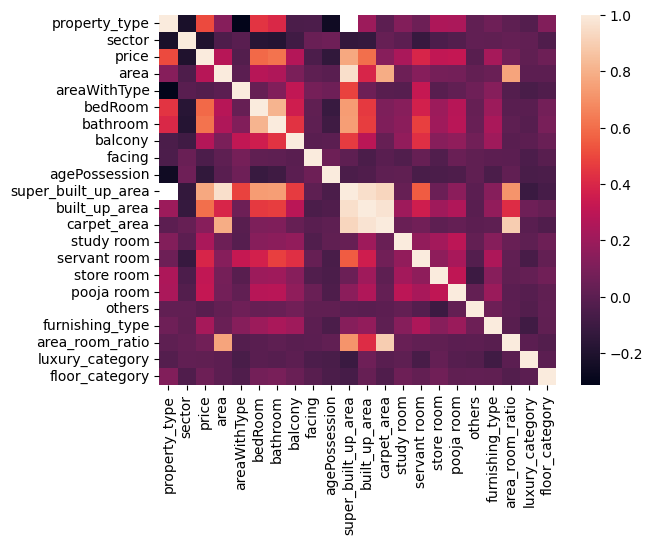

In [22]:
sns.heatmap(data_label_encoded.corr())

In [23]:
fi_df1 = data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coeff'})
fi_df1

,feature,corr_coeff
0,sector,-0.201436
1,price,1.000000
2,area,0.280210
3,areaWithType,-0.028059
4,bedRoom,0.589275
5,bathroom,0.611878
6,balcony,0.272118
7,facing,-0.048405
8,agePossession,-0.138977
9,super_built_up_area,0.770282


### Technique 2 - Random Forest Feature Importance

In [24]:
from sklearn.ensemble import RandomForestRegressor

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df2 = pd.DataFrame({
    'feature': X_label.columns,
    'rf_importance': rf_label.feature_importances_
}).sort_values(by='rf_importance', ascending=False)

fi_df2

,feature,rf_importance
2,area,0.512894
0,property_type,0.104917
1,sector,0.078276
10,built_up_area,0.071414
3,areaWithType,0.047696
18,area_room_ratio,0.027959
13,servant room,0.026524
5,bathroom,0.024731
4,bedRoom,0.024105
11,carpet_area,0.014977


### Technique 3 - Gradient Boosting Feature importances

In [25]:
X_label = X_label.dropna()
y_label = y_label.loc[X_label.index]  # Ensure y_label aligns with the new X_label


In [26]:
from sklearn.ensemble import GradientBoostingRegressor

# Train a Random Forest regressor on label encoded data

gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

fi_df3

,feature,gb_importance
9,super_built_up_area,0.412580
10,built_up_area,0.219760
1,sector,0.127077
8,agePossession,0.093618
17,furnishing_type,0.035208
11,carpet_area,0.024283
3,areaWithType,0.021908
18,area_room_ratio,0.020945
2,area,0.012535
5,bathroom,0.005927


In [27]:
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor

# Train a Gradient Boosting Regressor on label-encoded data
gb_label = GradientBoostingRegressor()
gb_label.fit(X_label, y_label)

# Extract feature importance scores for label-encoded data
fi_df3 = pd.DataFrame({
    'feature': X_label.columns,
    'gb_importance': gb_label.feature_importances_
}).sort_values(by='gb_importance', ascending=False)

print(fi_df3)


                feature  gb_importance
9   super_built_up_area       0.391793
10        built_up_area       0.218552
1                sector       0.126424
8         agePossession       0.093722
3          areaWithType       0.040741
17      furnishing_type       0.034850
18      area_room_ratio       0.025963
11          carpet_area       0.025901
2                  area       0.007997
7                facing       0.006777
5              bathroom       0.005927
15           pooja room       0.004432
13         servant room       0.003533
12           study room       0.003285
6               balcony       0.003155
20       floor_category       0.002511
19      luxury_category       0.001972
16               others       0.001583
14           store room       0.000795
4               bedRoom       0.000086
0         property_type       0.000000


### Technique 4 - Permutation Importance

In [28]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

X_train_label, X_test_label, y_train_label, y_test_label = train_test_split(X_label, y_label, test_size=0.2, random_state=42)

# Train a Random Forest regressor on label encoded data
rf_label = RandomForestRegressor(n_estimators=100, random_state=42)
rf_label.fit(X_train_label, y_train_label)

# Calculate Permutation Importance
perm_importance = permutation_importance(rf_label, X_test_label, y_test_label, n_repeats=30, random_state=42)

# Organize results into a DataFrame
fi_df4 = pd.DataFrame({
    'feature': X_label.columns,
    'permutation_importance': perm_importance.importances_mean
}).sort_values(by='permutation_importance', ascending=False)

fi_df4

,feature,permutation_importance
9,super_built_up_area,0.342020
1,sector,0.170320
10,built_up_area,0.054705
17,furnishing_type,0.042523
8,agePossession,0.031438
11,carpet_area,0.013117
7,facing,0.008119
6,balcony,0.004363
5,bathroom,0.002035
13,servant room,0.002011


### Technique 5 - LASSO

In [29]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_label)

# Train a LASSO regression model
# We'll use a relatively small value for alpha (the regularization strength) for demonstration purposes
lasso = Lasso(alpha=0.01, random_state=42)
lasso.fit(X_scaled, y_label)

# Extract coefficients
fi_df5 = pd.DataFrame({
    'feature': X_label.columns,
    'lasso_coeff': lasso.coef_
}).sort_values(by='lasso_coeff', ascending=False)

fi_df5


,feature,lasso_coeff
9,super_built_up_area,0.481990
10,built_up_area,0.355392
17,furnishing_type,0.264939
13,servant room,0.101723
11,carpet_area,0.086851
14,store room,0.050969
12,study room,0.043885
18,area_room_ratio,0.000000
2,area,0.000000
0,property_type,0.000000


### Technique 6 - RFE recurcive feature elimination

In [30]:
from sklearn.feature_selection import RFE

# Initialize the base estimator
estimator = RandomForestRegressor()

# Apply RFE on the label-encoded and standardized training data
selector_label = RFE(estimator, n_features_to_select=X_label.shape[1], step=1)
selector_label = selector_label.fit(X_label, y_label)

# Get the selected features based on RFE
selected_features = X_label.columns[selector_label.support_]

# Extract the coefficients for the selected features from the underlying linear regression model
selected_coefficients = selector_label.estimator_.feature_importances_

# Organize the results into a DataFrame
fi_df6 = pd.DataFrame({
    'feature': selected_features,
    'rfe_score': selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6


,feature,rfe_score
9,super_built_up_area,0.424487
10,built_up_area,0.145482
1,sector,0.101310
8,agePossession,0.089781
11,carpet_area,0.052607
2,area,0.047471
18,area_room_ratio,0.035216
3,areaWithType,0.028405
17,furnishing_type,0.027828
19,luxury_category,0.009019


### Technique 7 - Linear Regression Weights

In [31]:
# Train a linear regression model on the label-encoded and standardized training data
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression() 
lin_reg.fit(X_scaled, y_label)

# Extract coefficients
fi_df7 = pd.DataFrame({
    'feature': X_label.columns,
    'reg_coeffs': lin_reg.coef_
}).sort_values(by='reg_coeffs', ascending=False)

fi_df7


,feature,reg_coeffs
2,area,0.464411
9,super_built_up_area,0.433094
10,built_up_area,0.373106
17,furnishing_type,0.268421
13,servant room,0.115897
11,carpet_area,0.101306
12,study room,0.064455
14,store room,0.054886
5,bathroom,0.038272
16,others,0.009360


### Technique 8 - SHAP

In [32]:
! pip install shap

In [33]:
import shap

# Compute SHAP values using the trained Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_label, y_label)

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_label)

# Summing the absolute SHAP values across all samples to get an overall measure of feature importance
shap_sum = np.abs(shap_values).mean(axis=0)
shap_values


array([[ 0.00000000e+00,  1.14989547e-01, -3.10322966e-02, ...,
        -1.45257378e-02,  3.92795212e-02,  1.81694032e-02],
       [ 0.00000000e+00,  1.72963567e-01, -4.47508568e-02, ...,
        -1.98265267e-02,  8.15532838e-02, -2.88140423e-03],
       [ 0.00000000e+00,  3.07445392e-01, -1.61173793e-02, ...,
        -3.24401612e-02, -2.07289709e-02,  6.24752201e-02],
       ...,
       [ 0.00000000e+00, -5.12420891e-01, -3.91178067e-02, ...,
        -1.46192075e-02,  5.02997960e-02, -6.61993617e-03],
       [ 0.00000000e+00, -2.50759592e-01, -4.38298714e-02, ...,
        -3.43030603e-02, -1.48495568e-02,  6.03121466e-03],
       [ 0.00000000e+00,  3.09390931e-01,  4.57122374e-03, ...,
        -9.39889777e-03, -1.31587960e-02, -3.32046037e-04]])

In [34]:
fi_df8 = pd.DataFrame({
    'feature': X_label.columns,
    'SHAP_score': np.abs(shap_values).mean(axis=0)
}).sort_values(by='SHAP_score', ascending=False)

fi_df8

,feature,SHAP_score
9,super_built_up_area,0.458531
1,sector,0.219337
10,built_up_area,0.151240
8,agePossession,0.056704
17,furnishing_type,0.053464
2,area,0.051610
18,area_room_ratio,0.041021
11,carpet_area,0.040715
19,luxury_category,0.031484
6,balcony,0.018610


In [35]:
final_fi_df = fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [36]:
final_fi_df


,corr_coeff,rf_importance,gb_importance,permutation_importance,lasso_coeff,rfe_score,reg_coeffs,SHAP_score
feature,,,,,,,,
sector,-0.201436,0.078276,0.126424,0.170320,-0.095924,0.101310,-0.100506,0.219337
area,0.280210,0.512894,0.007997,-0.027460,0.000000,0.047471,0.464411,0.051610
areaWithType,-0.028059,0.047696,0.040741,-0.008043,0.000000,0.028405,-0.013313,0.017212
bedRoom,0.589275,0.024105,0.000086,-0.000571,-0.121692,0.001755,-0.435622,0.003179
bathroom,0.611878,0.024731,0.005927,0.002035,0.000000,0.006597,0.038272,0.005575
balcony,0.272118,0.007003,0.003155,0.004363,-0.038945,0.008446,-0.041696,0.018610
facing,-0.048405,0.014113,0.006777,0.008119,-0.037061,0.008012,-0.040758,0.016534
agePossession,-0.138977,0.007528,0.093722,0.031438,-0.070830,0.089781,-0.079913,0.056704
super_built_up_area,0.770282,0.006425,0.391793,0.342020,0.481990,0.424487,0.433094,0.458531


In [37]:
# normalize the score
final_fi_df = final_fi_df.divide(final_fi_df.sum(axis=0), axis=1)

In [38]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_score']].mean(axis=1).sort_values(ascending=False)

feature
super_built_up_area    0.352612
sector                 0.155112
built_up_area          0.131855
area                   0.125403
agePossession          0.058091
furnishing_type        0.036661
carpet_area            0.030125
areaWithType           0.024751
area_room_ratio        0.019809
facing                 0.011517
bathroom               0.009625
luxury_category        0.008651
servant room           0.008466
balcony                0.008417
bedRoom                0.006100
study room             0.004444
floor_category         0.003918
others                 0.001653
store room             0.001443
pooja room             0.001344
dtype: float64

In [39]:
# to drop pooja room, study room, others
X_label

,property_type,sector,area,areaWithType,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,area_room_ratio,luxury_category,floor_category
5,0.0,19.0,2217.0,1857.0,3,3,3.0,2.0,1.0,2217.0,2210.0,1720.00,0,1,0,0,0,0,739.000000,0.0,0.0
9,0.0,59.0,1997.0,1702.0,3,3,4.0,2.0,0.0,1997.0,1950.0,1850.00,0,0,0,0,0,1,665.666667,0.0,2.0
18,0.0,35.0,1550.0,1514.0,3,3,2.0,7.0,2.0,1777.0,1700.0,1550.00,0,1,0,0,0,0,516.666667,2.0,0.0
26,0.0,6.0,1650.0,1379.0,3,3,3.0,0.0,3.0,1650.0,1300.0,1022.58,0,1,0,0,0,0,550.000000,1.0,2.0
27,0.0,105.0,1375.0,1655.0,3,4,3.0,1.0,3.0,1950.0,1525.0,1375.00,0,1,0,0,0,1,458.333333,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3531,0.0,59.0,1794.0,1526.0,3,3,4.0,1.0,0.0,1794.0,1790.0,1450.00,0,0,0,0,1,1,598.000000,0.0,0.0
3533,0.0,8.0,1446.0,1252.0,2,2,4.0,0.0,3.0,1446.0,1269.0,777.00,1,0,0,0,0,0,723.000000,2.0,2.0
3537,0.0,99.0,2120.0,1788.0,3,4,2.0,1.0,3.0,2120.0,1900.0,1800.00,0,1,0,0,0,1,706.666667,0.0,2.0
3538,0.0,97.0,1245.0,1101.0,2,2,2.0,0.0,3.0,1245.0,1150.0,1020.00,0,0,0,0,1,1,622.500000,2.0,0.0


In [40]:
# with all the cols
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label, y_label, cv=5, scoring='r2')

In [41]:
scores.mean()

np.float64(0.7765463597682114)

In [42]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)

scores = cross_val_score(rf, X_label.drop(columns=['pooja room', 'study room', 'others']), y_label, cv=5, scoring='r2')

In [43]:
scores.mean()

np.float64(0.7809357363849441)

In [44]:
export_df = X_label.drop(columns=['pooja room', 'study room', 'others'])
export_df['price'] = y_label

In [45]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv', index=False)

In [46]:
export_df

,property_type,sector,area,areaWithType,bedRoom,bathroom,balcony,facing,agePossession,super_built_up_area,built_up_area,carpet_area,servant room,store room,furnishing_type,area_room_ratio,luxury_category,floor_category,price
5,0.0,19.0,2217.0,1857.0,3,3,3.0,2.0,1.0,2217.0,2210.0,1720.00,1,0,0,739.000000,0.0,0.0,2.35
9,0.0,59.0,1997.0,1702.0,3,3,4.0,2.0,0.0,1997.0,1950.0,1850.00,0,0,1,665.666667,0.0,2.0,2.35
18,0.0,35.0,1550.0,1514.0,3,3,2.0,7.0,2.0,1777.0,1700.0,1550.00,1,0,0,516.666667,2.0,0.0,2.25
26,0.0,6.0,1650.0,1379.0,3,3,3.0,0.0,3.0,1650.0,1300.0,1022.58,1,0,0,550.000000,1.0,2.0,1.40
27,0.0,105.0,1375.0,1655.0,3,4,3.0,1.0,3.0,1950.0,1525.0,1375.00,1,0,1,458.333333,2.0,1.0,0.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3531,0.0,59.0,1794.0,1526.0,3,3,4.0,1.0,0.0,1794.0,1790.0,1450.00,0,0,1,598.000000,0.0,0.0,1.88
3533,0.0,8.0,1446.0,1252.0,2,2,4.0,0.0,3.0,1446.0,1269.0,777.00,0,0,0,723.000000,2.0,2.0,0.85
3537,0.0,99.0,2120.0,1788.0,3,4,2.0,1.0,3.0,2120.0,1900.0,1800.00,1,0,1,706.666667,0.0,2.0,1.25
3538,0.0,97.0,1245.0,1101.0,2,2,2.0,0.0,3.0,1245.0,1150.0,1020.00,0,0,1,622.500000,2.0,0.0,0.75
